In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
#Load the bed coverage and flagstat files
gam_steph_bedcov_df = pd.read_csv("./gambiae_steph_bedcov.csv")
gam_steph_flagstat_df = pd.read_csv("./gambiae_steph_flagstat.csv")
gam_ara_bedcov_df = pd.read_csv("./gambiae_ara_bedcov.csv")
gam_ara_flagstat_df = pd.read_csv("./gambiae_ara_flagstat.csv")

#Load final variants file from previous analysis
gambiae_merged_df = pd.read_csv("./GAMBIAE/gambiae_merged.csv")
arabiensis_merged_df = pd.read_csv("./ARABIENSIS/arabiensis_merged.csv")
steph_merged_df = pd.read_csv("./STEPHENSI/steph_merged.csv")

In [3]:
gam_steph_bedcov_df

,barcode,chrom,start,length,end,mean_cov,name,cov_gr100_per,target,total_cov,cov_gr100,n_reads,species
0,barcode01,CM023248,60913370,962,60914332,8823.464657,Ace1-280S,96.985447,Ace1-280S,8488173,933,9755,An.stephensi
1,barcode01,CM023249,8352786,791,8353577,1934.603034,Gaba-296G,94.437421,Gaba-296G,1530271,747,2578,An.stephensi
2,barcode01,CM023249,70580365,699,70581064,9524.449213,Gste2-119V,99.570815,Gste2-119V,6657590,696,10707,An.stephensi
3,barcode01,CM023249,42817337,545,42817882,7526.280734,Vgsc-L995S,86.605505,Vgsc-L995S,4101823,472,9890,An.stephensi
4,barcode01,CM023249,42830276,727,42831003,669.225585,Vgsc-N1570Y,97.386520,Vgsc-N1570Y,486527,708,829,An.stephensi
...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,unclassified,AgamP4_2L,25428663,1104,25429767,17912.966490,Gaba-296G,100.000000,Gaba-296G,19775915,1104,19440,An.gambiae
800,unclassified,AgamP4_3R,28597892,842,28598734,48880.296910,Gste2-119V,100.000000,Gste2-119V,41157210,842,52512,An.gambiae
801,unclassified,AgamP4_2L,2422485,978,2423463,62590.302660,Vgsc-L995S,100.000000,Vgsc-L995S,61213316,978,66251,An.gambiae
802,unclassified,AgamP4_2L,2428804,1074,2429878,24145.568900,Vgsc-N1570Y,100.000000,Vgsc-N1570Y,25932341,1074,25727,An.gambiae


In [4]:
gam_ara_bedcov_df

,barcode,chrom,start,length,end,mean_cov,name,cov_gr100_per,target,total_cov,cov_gr100,n_reads,species
0,barcode01,CM029352,3438914,1075,3439989,7854.754419,Ace1-280S,98.976744,Ace1-280S,8443861,1064,8470,An.arabiensis
1,barcode01,CM029352,100183490,1106,100184596,4375.256781,Gaba-296G,98.643761,Gaba-296G,4839034,1091,4874,An.arabiensis
2,barcode01,CM029352,63292452,1015,63293467,10126.378330,Vgsc-L995S,96.354680,Vgsc-L995S,10278274,978,10908,An.arabiensis
3,barcode01,CM029352,63298758,1103,63299861,2288.265639,Vgsc-N1570Y,97.280145,Vgsc-N1570Y,2523957,1073,2481,An.arabiensis
4,barcode01,CM029352,63261133,1163,63262296,882.406707,Vgsc-V402,97.334480,Vgsc-V402,1026239,1132,1007,An.arabiensis
...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,unclassified,AgamP4_2L,25428663,1104,25429767,17912.966490,Gaba-296G,100.000000,Gaba-296G,19775915,1104,19440,An.gambiae
830,unclassified,AgamP4_3R,28597892,842,28598734,48880.296910,Gste2-119V,100.000000,Gste2-119V,41157210,842,52512,An.gambiae
831,unclassified,AgamP4_2L,2422485,978,2423463,62590.302660,Vgsc-L995S,100.000000,Vgsc-L995S,61213316,978,66251,An.gambiae
832,unclassified,AgamP4_2L,2428804,1074,2429878,24145.568900,Vgsc-N1570Y,100.000000,Vgsc-N1570Y,25932341,1074,25727,An.gambiae


/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 23.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 53.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Ace1-280S'),
  Text(1, 0, 'Gaba-296G'),
  Text(2, 0, 'Vgsc-L995S'),
  Text(3, 0, 'Vgsc-N1570Y'),
  Text(4, 0, 'Vgsc-V402'),
  Text(5, 0, 'Gste2-119V')])

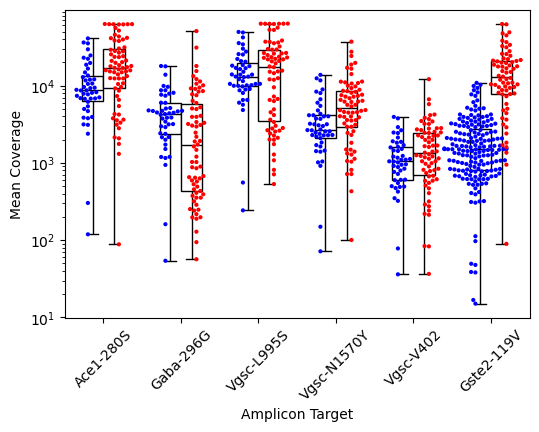

In [5]:
#Create a summary plot of mean coverage
plt.figure(figsize=(6, 4))

#palette for swamplot and boxplot
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

# swarm plot
sns.swarmplot(x="target", y="mean_cov",hue='species',palette=palette, data=gam_ara_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=True,legend=None)
plt.yscale('log')

# box plot
sns.boxplot(x="target", y="mean_cov",hue='species',data=gam_ara_bedcov_df,palette=palette2,whis=np.inf,color="White",linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
plt.xlabel('Amplicon Target')
plt.ylabel('Mean Coverage')
plt.xticks(rotation=45)



In [6]:

medians = gam_ara_bedcov_df.groupby(['target', 'species'])['mean_cov'].median()
print(medians)


target       species      
Ace1-280S    An.arabiensis     8656.190232
             An.gambiae       16934.172315
Gaba-296G    An.arabiensis     4326.068716
             An.gambiae        1678.671649
Gste2-119V   An.arabiensis     1501.756741
             An.gambiae       12810.029690
Vgsc-L995S   An.arabiensis    13066.235465
             An.gambiae       17482.368610
Vgsc-N1570Y  An.arabiensis     2677.781958
             An.gambiae        5100.571229
Vgsc-V402    An.arabiensis     1042.759673
             An.gambiae        1326.658633
Name: mean_cov, dtype: float64


/tmp/ipykernel_8126/3627226247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=True)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 41.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


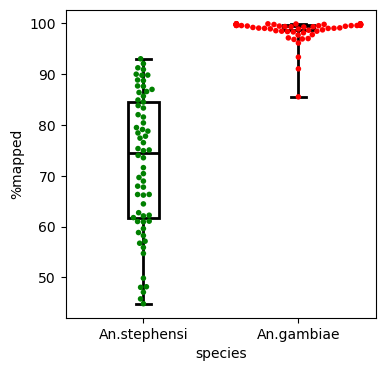

In [7]:
plt.figure(figsize=(4, 4))
# Create a color palette for different species
palette = {'An.gambiae': 'red', 'An. arabiensis': 'blue', 'An.stephensi': 'green'}

# swarm plot
sns.swarmplot(x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=True)

# box plot
sns.boxplot(x="species", y="%mapped",data=gam_steph_flagstat_df,whis=np.inf, color="White",linewidth=2,linecolor='black',width=0.2)

plt.show()


/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 56.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/se

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Ace1-280S'),
  Text(1, 0, 'Gaba-296G'),
  Text(2, 0, 'Gste2-119V'),
  Text(3, 0, 'Vgsc-L995S'),
  Text(4, 0, 'Vgsc-N1570Y'),
  Text(5, 0, 'Vgsc-V402')])

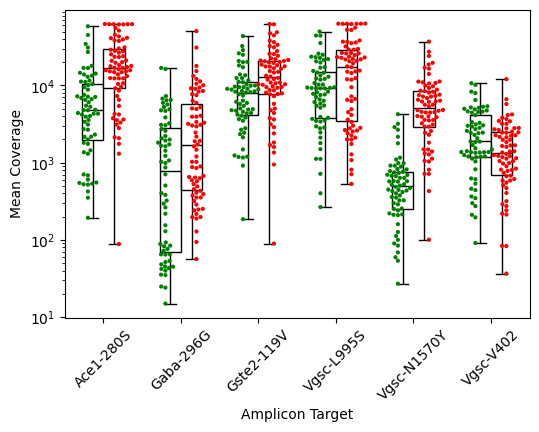

In [8]:
plt.figure(figsize=(6, 4))

#palette for swamplot and boxplot
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

# swarm plot
sns.swarmplot(x="target", y="mean_cov",hue='species',palette=palette, data=gam_steph_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=True,legend=None)
plt.yscale('log')


# box plot
sns.boxplot(x="target", y="mean_cov",hue='species',data=gam_steph_bedcov_df,palette=palette2,whis=np.inf,color="White",linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
plt.xlabel('Amplicon Target')
plt.ylabel('Mean Coverage')
plt.xticks(rotation=45)



/tmp/ipykernel_8126/2372827488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(ax=axis[0],x="species", y="%mapped",palette=palette, data=gam_ara_flagstat_df,edgecolor="black", size=4, native_scale=True,legend=None)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 17.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.7% of the points cannot be placed; you may want to decre

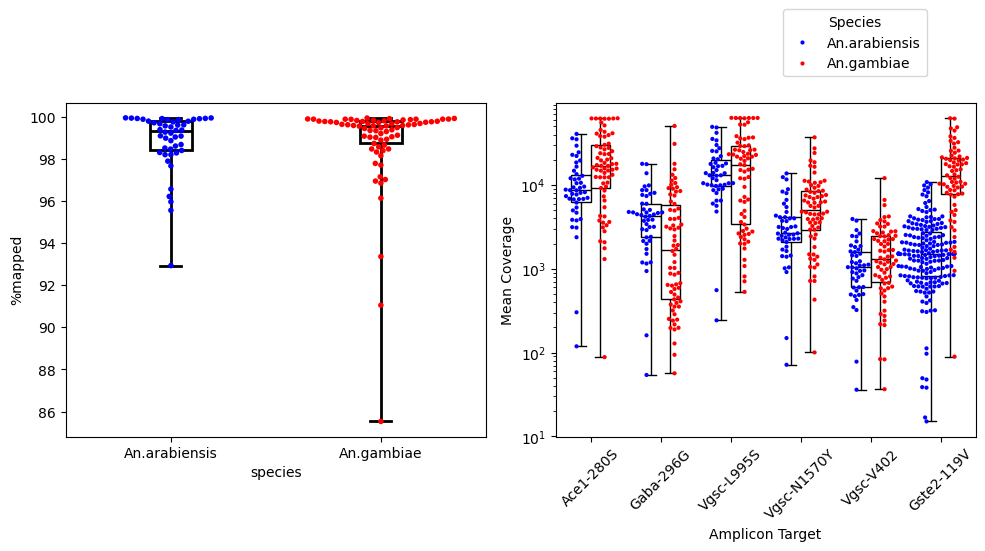

In [9]:
# Create a color palette for different species
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

figure, axis=plt.subplots(1,2, figsize=(10,6))
# swarm plot and box plot 1
sns.swarmplot(ax=axis[0],x="species", y="%mapped",palette=palette, data=gam_ara_flagstat_df,edgecolor="black", size=4, native_scale=True,legend=None)
sns.boxplot(ax=axis[0],x="species", y="%mapped",data=gam_ara_flagstat_df,whis=np.inf, color="White",linewidth=2,linecolor='black',width=0.2,legend=None)


# swarm plot and box plot 2
sns.swarmplot(ax=axis[1],x="target", y="mean_cov",hue='species',palette=palette, data=gam_ara_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=True,legend='auto')
axis[1].set_yscale('log')
sns.boxplot(ax=axis[1],x="target", y="mean_cov",hue='species',data=gam_ara_bedcov_df,palette=palette2,whis=np.inf,color="White",dodge='True',linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
axis[1].set_xlabel('Amplicon Target')
axis[1].set_ylabel('Mean Coverage')
axis[1].tick_params(axis='x', rotation=45)

axis[1].legend(title='Species', loc='upper right',bbox_to_anchor=(0.9, 1.3))
plt.tight_layout()

/tmp/ipykernel_8126/1842956139.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(ax=axis[0],x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=True, legend=None)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 31.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to de

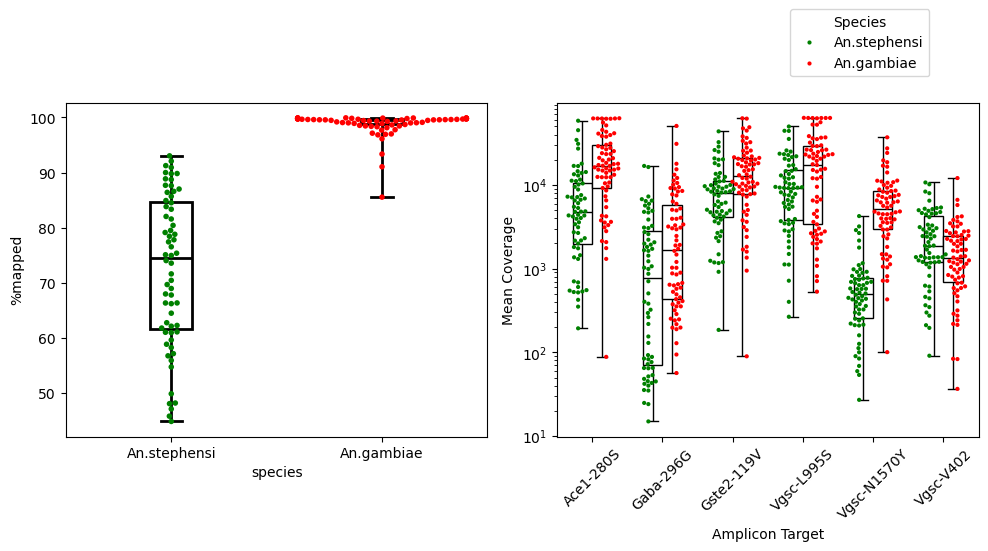

In [10]:
# Create a color palette for different species
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

figure, axis=plt.subplots(1,2, figsize=(10,6))
# swarm plot and box plot 1
sns.swarmplot(ax=axis[0],x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=True, legend=None)
sns.boxplot(ax=axis[0],x="species", y="%mapped",data=gam_steph_flagstat_df,whis=np.inf, color="White",linewidth=2,linecolor='black',width=0.2, legend=None)


# swarm plot and box plot 2
sns.swarmplot(ax=axis[1],x="target", y="mean_cov",hue='species',palette=palette, data=gam_steph_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=True,legend='auto')
axis[1].set_yscale('log')
sns.boxplot(ax=axis[1],x="target", y="mean_cov",hue='species',data=gam_steph_bedcov_df,palette=palette2,whis=np.inf,color="White",linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
axis[1].set_xlabel('Amplicon Target')
axis[1].set_ylabel('Mean Coverage')
axis[1].tick_params(axis='x', rotation=45)

axis[1].legend(title='Species', loc='upper right',bbox_to_anchor=(0.9, 1.3))
plt.tight_layout()

In [11]:
#convert the dataframe to arrays for ploting allele frequencies
#Gambiae
# SNPS data
positions_g = np.array(gambiae_merged_df["Label"])
aa_change_g = np.array(gambiae_merged_df["alt1"])
# Genotype data
snps_gt_00_g = -np.array(gambiae_merged_df["GT:0/0"])  # GT 0/0
snps_gt_01_g = -np.array(gambiae_merged_df["GT:0/1"])  # GT 0/1
snps_gt_11_g = -np.array(gambiae_merged_df["GT:1/1"])  # GT 1/1

#Arabiensis
# SNPS data
positions_a = np.array(arabiensis_merged_df["Label"])
aa_change_a = np.array(arabiensis_merged_df["alt1"])
# Genotype data
snps_gt_00_a = -np.array(arabiensis_merged_df["GT:0/0"])  # GT 0/0
snps_gt_01_a = -np.array(arabiensis_merged_df["GT:0/1"])  # GT 0/1
snps_gt_11_a = -np.array(arabiensis_merged_df["GT:1/1"])  # GT 1/1

#Stephensi
# SNPS data
positions_s = np.array(steph_merged_df["Label"])
aa_change_s = np.array(steph_merged_df["alt1"])
# Genotype data
snps_gt_00_s = -np.array(steph_merged_df["GT:0/0"])  # GT 0/0
snps_gt_01_s = -np.array(steph_merged_df["GT:0/1"])  # GT 0/1
snps_gt_11_s = -np.array(steph_merged_df["GT:1/1"])  # GT 1/1


/tmp/ipykernel_8126/2434980996.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(ax=axis[0,0],x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=False, legend=None)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 29.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to

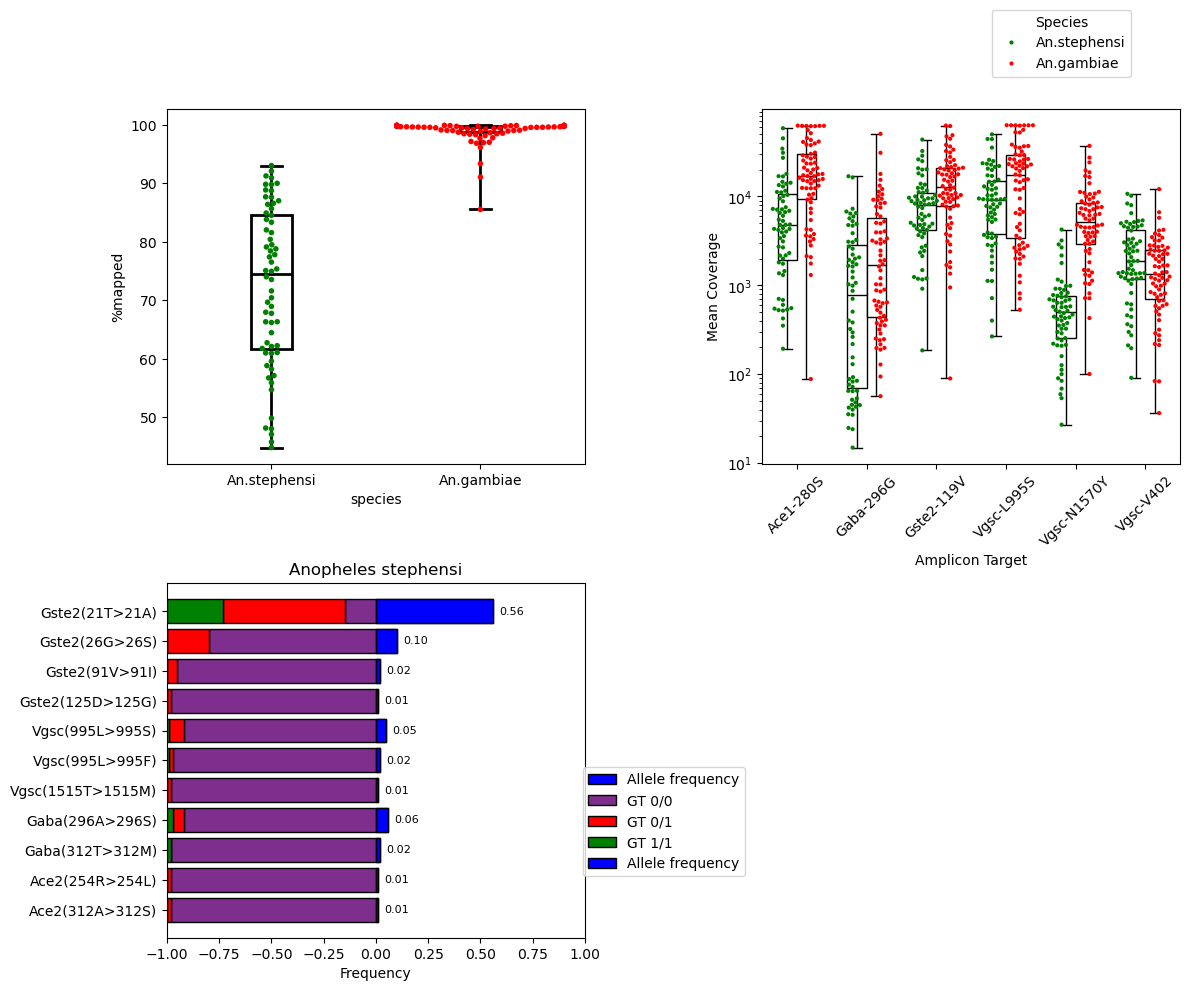

In [12]:
# Create a color palette for different species
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

figure, axis=plt.subplots(2,2, figsize=(12,10))
# swarm plot and box plot 1
sns.swarmplot(ax=axis[0,0],x="species", y="%mapped",palette=palette, data=gam_steph_flagstat_df,edgecolor="black", size=4, native_scale=False, legend=None)
sns.boxplot(ax=axis[0,0],x="species", y="%mapped",data=gam_steph_flagstat_df,whis=np.inf, color="White",linewidth=2,linecolor='black',width=0.2, legend=None)


# swarm plot and box plot 2
sns.swarmplot(ax=axis[0,1],x="target", y="mean_cov",hue='species',palette=palette, data=gam_steph_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=False,legend='auto')
axis[0,1].set_yscale('log')
sns.boxplot(ax=axis[0,1],x="target", y="mean_cov",hue='species',data=gam_steph_bedcov_df,palette=palette2,whis=np.inf,color="White",linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
axis[0,1].set_xlabel('Amplicon Target')
axis[0,1].set_ylabel('Mean Coverage')
axis[0,1].tick_params(axis='x', rotation=45)
axis[0,1].legend(title='Species', loc='upper right',bbox_to_anchor=(0.9, 1.3))

# Plot the allele frequency
axis[1,0].barh(positions_s, aa_change_s, color='blue', edgecolor='black', label='Allele frequency')


# Plot stacked genotype frequencies
bottom = np.zeros(len(positions_s))
axis[1,0].barh(positions_s, snps_gt_00_s, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00_s
axis[1,0].barh(positions_s, snps_gt_01_s, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01_s
axis[1,0].barh(positions_s, snps_gt_11_s, left=bottom, color='green', edgecolor='black', label='GT 1/1')

# Plot allele frequency bar
bars = axis[1,0].barh(positions_s, aa_change_s, color='blue', edgecolor='black', label='Allele frequency')

# Add value labels for allele frequency
for bar in bars:
    width = bar.get_width()
    
    # If negative values, shift text to the left
    if width < 0:
        x_pos = width - 0.03       # slightly left of the bar
        ha = 'right'
    else:
        x_pos = width + 0.03       # slightly right of the bar
        ha = 'left'
    
    axis[1,0].text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        ha=ha,
        fontsize=8
    )


# Adding labels and title
axis[1,0].set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
axis[1,0].set_title('Anopheles stephensi')
axis[1,0].legend(loc='upper right',bbox_to_anchor=(1.4, 0.5))
axis[1,0].set_xlim(-1, 1)

axis[1,1].remove()

plt.tight_layout()

/tmp/ipykernel_8126/4101116615.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(ax=axis[0,0],x="species", y="%mapped",palette=palette, data=gam_ara_flagstat_df,edgecolor="black", size=4, native_scale=True, legend=None)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 21.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/cynthia/.mambaforge/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 49.5% of the points cannot be placed; you may want to de

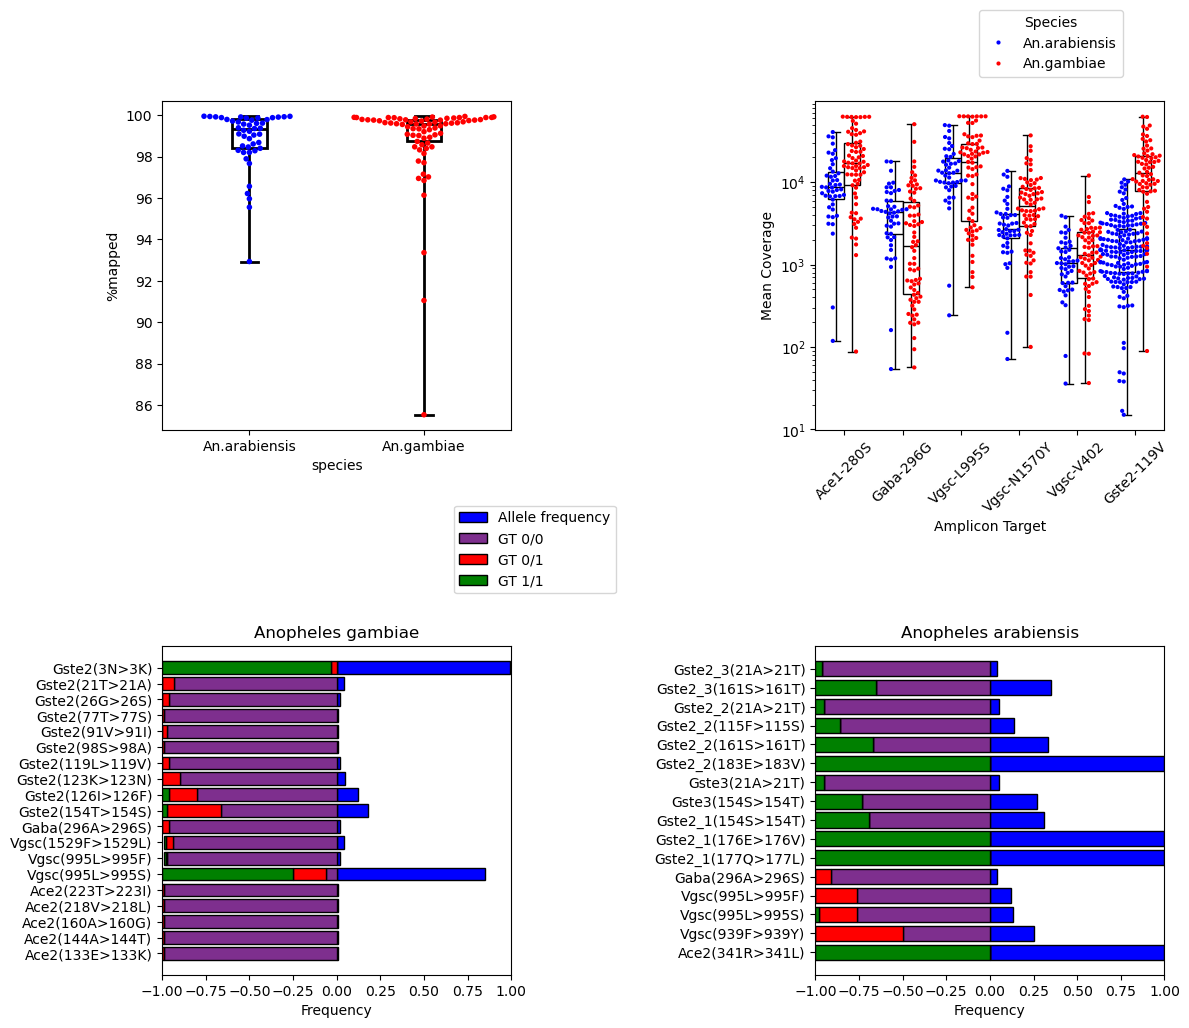

In [13]:
# Create a color palette for different species
palette = {'An.gambiae': 'red', 'An.arabiensis': 'blue', 'An.stephensi': 'green'}
palette2 = {'An.gambiae': 'white', 'An.arabiensis': 'white', 'An.stephensi': 'white'}

figure, axis=plt.subplots(2,2, figsize=(12,10.5))
# swarm plot and box plot 1
sns.swarmplot(ax=axis[0,0],x="species", y="%mapped",palette=palette, data=gam_ara_flagstat_df,edgecolor="black", size=4, native_scale=True, legend=None)
sns.boxplot(ax=axis[0,0],x="species", y="%mapped",data=gam_ara_flagstat_df,whis=np.inf, color="White",linewidth=2,linecolor='black',width=0.2, legend=None)


# swarm plot and box plot 2
sns.swarmplot(ax=axis[0,1],x="target", y="mean_cov",hue='species',palette=palette, data=gam_ara_bedcov_df,edgecolor="black",dodge='True', size=3, native_scale=True,legend='auto')
axis[0,1].set_yscale('log')
sns.boxplot(ax=axis[0,1],x="target", y="mean_cov",hue='species',data=gam_ara_bedcov_df,palette=palette2,whis=np.inf,color="White",linewidth=1,legend=None,linecolor='black',width=0.55)

#label the axes
axis[0,1].set_xlabel('Amplicon Target')
axis[0,1].set_ylabel('Mean Coverage')
axis[0,1].tick_params(axis='x', rotation=45)
axis[0,1].legend(title='Species', loc='upper right',bbox_to_anchor=(0.9, 1.3))

# Plot the allele frequency
axis[1,0].barh(positions_g, aa_change_g, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions_g))
axis[1,0].barh(positions_g, snps_gt_00_g, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00_g
axis[1,0].barh(positions_g, snps_gt_01_g, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01_g
axis[1,0].barh(positions_g, snps_gt_11_g, left=bottom, color='green', edgecolor='black', label='GT 1/1')


# Adding labels and title
axis[1,0].set_xlabel('Frequency')
axis[1,0].set_title('Anopheles gambiae')
axis[1,0].legend(loc='upper right',bbox_to_anchor=(1.32, 1.45))
axis[1,0].set_xlim(-1, 1)

# Plot the allele frequency
axis[1,1].barh(positions_a, aa_change_a, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions_a))
axis[1,1].barh(positions_a, snps_gt_00_a, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00_a
axis[1,1].barh(positions_a, snps_gt_01_a, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01_a
axis[1,1].barh(positions_a, snps_gt_11_a, left=bottom, color='green', edgecolor='black', label='GT 1/1')


# Adding labels and title
axis[1,1].set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
axis[1,1].set_title('Anopheles arabiensis')
#ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.3))

axis[1,1].set_xlim(-1, 1)
plt.tight_layout()

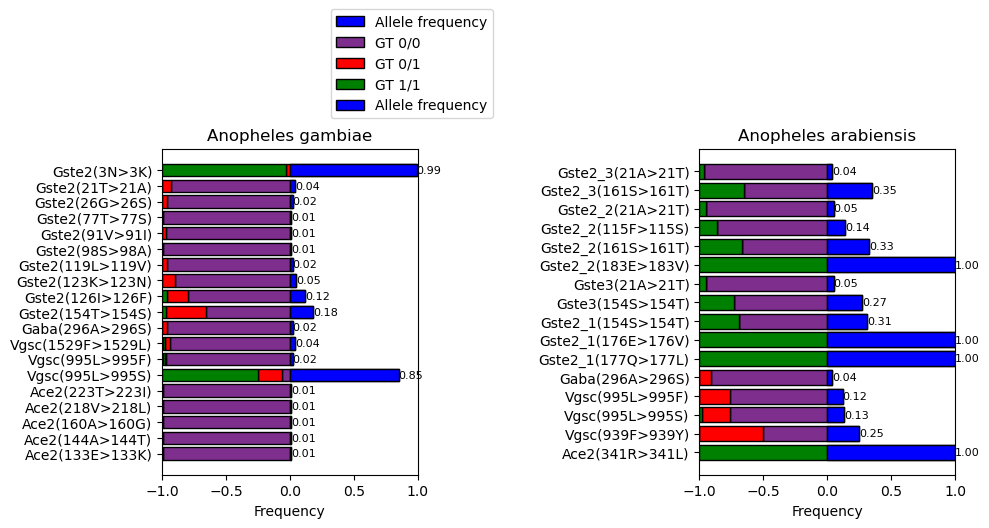

In [14]:

figure, axis=plt.subplots(1,2, figsize=(10,6))
# Plot the allele frequency
axis[0].barh(positions_g, aa_change_g, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions_g))
axis[0].barh(positions_g, snps_gt_00_g, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00_g
axis[0].barh(positions_g, snps_gt_01_g, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01_g
axis[0].barh(positions_g, snps_gt_11_g, left=bottom, color='green', edgecolor='black', label='GT 1/1')
# After plotting allele frequency for gambiae
bars = axis[0].barh(positions_g, aa_change_g, color='blue', edgecolor='black', label='Allele frequency')

# Add value labels
for bar in bars:
    width = bar.get_width()
    axis[0].text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', va='center', ha='left', fontsize=8)


# Adding labels and title
axis[0].set_xlabel('Frequency')
axis[0].set_title('Anopheles gambiae')
axis[0].legend(loc='upper right',bbox_to_anchor=(1.32, 1.45))
axis[0].set_xlim(-1, 1)

# Plot the allele frequency
axis[1].barh(positions_a, aa_change_a, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions_a))
axis[1].barh(positions_a, snps_gt_00_a, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00_a
axis[1].barh(positions_a, snps_gt_01_a, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01_a
axis[1].barh(positions_a, snps_gt_11_a, left=bottom, color='green', edgecolor='black', label='GT 1/1')

bars = axis[1].barh(positions_a, aa_change_a, color='blue', edgecolor='black', label='Allele frequency')

# Add value labels
for bar in bars:
    width = bar.get_width()
    axis[1].text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', va='center', ha='left', fontsize=8)

# Adding labels and title
axis[1].set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
axis[1].set_title('Anopheles arabiensis')
#ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.3))
axis[1].set_xlim(-1, 1)
plt.tight_layout()
